# Tohoku: Optimising Manning's n for Each DEM

`notebook_tohoku_open_elevation.ipynb` takes its elevation from one of two
DEMs, selected by `elevation_source`:

- **`'open'`** -- the NOAA NCEI / GEBCO GeoTIFF, 15 arcsec (~450 m);
- **`'pts'`** -- `Tohoku.pts` (~150 m) overlaid where it has coverage, with
  the GeoTIFF filling the deep ocean.

Manning's *n* here is an effective value standing in for bed roughness,
buildings and coastal defences the DEM cannot resolve, so it is tied to the
DEM: the finer `Tohoku.pts` lets more water through the coastal strip and
wants more roughness.  This notebook sweeps *n* on both DEMs with everything
else held fixed, and picks the value for each.

**What is fixed.**  The source is the notebook's: the split fault at the
Global CMT moment (M0 = 5.3e22, 90% on the 5 deg near-trench segment) with the
Tanioka & Satake horizontal-push term, DE_ader2, Flather boundaries, a 2 hour
run on the ~355 000-triangle mesh.  Nothing in the source is fitted.

**Why friction can be tuned on its own.**  Friction is negligible in 5700 m of
water, so the DART 21418 peak does not move with *n* (checked below).  The
source sets the far field; friction then sets the coast.

**Scoring.**  Aida's *K* (geometric mean of observed/modelled; 1 = unbiased,
< 1 = model high) and *&kappa;* (geometric standard deviation) against the TTJS
survey in the study area, `project.study_extent_ll`.  Survey marks are matched
with the notebook's criterion -- the nearest cell inundated to at least
**0.10 m within 500 m**.  The older loose criterion (0.01 m, 1500 m), which
`calibrate_deterministic.py` still prints and records, is shown alongside for
comparison with `calibration_results.jsonl`.

In [1]:
import os, subprocess, sys, time
import numpy as np
import matplotlib.pyplot as plt
import anuga
import utm
from scipy.spatial import cKDTree

%matplotlib inline

try:
    os.chdir('Tohoku')
except OSError:
    pass
print(f'Working directory: {os.getcwd()}')

import project
from tsunami_observations import load_ttjs, in_extent_ll

Working directory: /home/steve/Projects/Tohoku
Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 15000000                 88753.41           5916
Interior 3600000                  30241.19           8400
Interior 60000                    11288.13           188135
Bounding 15000000                 371317.27          24754
Estimated total number of triangles: 324581
Number of triangles: 324581
Note: This is generally about 20% less than the final amount
output directory: /home/steve/Projects/Tohoku/_output_Caltech
source directory: /home/steve/Projects/Tohoku/sources/Caltech.pts


## The sweep

Each run goes through `calibrate_deterministic.py`, which builds the same
domain as the notebook, applies the source, evolves and writes
`calib_<tag>.sww`.  Runs whose `.sww` already exists are skipped, so this
cell is cheap to re-run and extending `frictions` only runs the new values.

Each run takes ~80 s on the GPU; the first `pts` run also builds and caches
the `Tohoku.pts` interpolation (`_pts_elev_<ncells>.npy`, ~15 s).  **Run one
sweep at a time** -- there is one GPU.

In [2]:
dems      = ['open', 'pts']
frictions = [0.030, 0.035, 0.040, 0.045, 0.050, 0.055, 0.060]

# The notebook's source, spelled out for the driver.
source_args = ['--source', 'split', '--split-frac', '0.9', '--M0', '5.3e22',
               '--dip1', '5', '--width1', '80000', '--top1', '2000',
               '--dip2', '15', '--width2', '120000', '--sig-u', '0.20']


def tag(dem, n):
    return f'fric_{dem}_n{n:.3f}'


for dem in dems:
    for n in frictions:
        sww = f'calib_{tag(dem, n)}.sww'
        if os.path.exists(sww):
            continue
        t0 = time.time()
        print(f'running {tag(dem, n)} ...', end=' ', flush=True)
        subprocess.run([sys.executable, 'calibrate_deterministic.py', *source_args,
                        '--elevation-source', dem, '--friction', f'{n}',
                        '--tag', tag(dem, n)],
                       check=True, capture_output=True)
        print(f'{time.time() - t0:.0f} s')

print('all runs present')

all runs present


## Scoring

Everything is read back from the `.sww` files.  `max_stage` and `max_depth`
are the every-timestep maxima written by the max-quantities operator, not a
scan of the 2-minute frames.

In [3]:
survey = in_extent_ll(load_ttjs(types='IR', reliability='AB'), project.study_extent_ll)
h_obs  = survey['height']            # tide = 0.0 in these runs
dart_e, dart_n, _, _ = utm.from_latlon(38.711, 148.694, force_zone_number=54)

criteria = {'strict': (0.10, 500.0),     # the notebook's
            'loose':  (0.01, 1500.0)}    # calibrate_deterministic.py's


def score(sww_file):
    sp = anuga.SWW_plotter(sww_file, absolute=True)
    max_stage = np.asarray(sp.max_stage)
    max_depth = np.asarray(sp.max_depth)

    cell = int(np.argmin((sp.xc - dart_e) ** 2 + (sp.yc - dart_n) ** 2))
    series = np.asarray(sp.stage)[:, cell]
    out = dict(dart=series.max(), dart_t=np.asarray(sp.time)[series.argmax()] / 60)

    for name, (depth, radius) in criteria.items():
        wet = max_depth >= depth
        d, j = cKDTree(np.column_stack([sp.xc[wet], sp.yc[wet]])).query(
            np.column_stack([survey['east'], survey['north']]),
            distance_upper_bound=radius)
        h_mod = np.full(h_obs.shape, np.nan)
        hit = np.isfinite(d)
        h_mod[hit] = max_stage[wet][j[hit]]

        paired = np.isfinite(h_mod) & (h_mod > 0) & (h_obs > 0)
        logr = np.log(h_obs[paired] / h_mod[paired])
        out[name] = dict(
            K=np.exp(logr.mean()),
            kappa=np.exp(logr.std()),
            bias=np.mean(h_mod[paired] - h_obs[paired]),
            rms=np.sqrt(np.mean((h_mod[paired] - h_obs[paired]) ** 2)),
            paired=int(paired.sum()),
            dry=int((~np.isfinite(h_mod)).sum()))
    return out


results = {dem: {n: score(f'calib_{tag(dem, n)}.sww') for n in frictions}
           for dem in dems}
print(f'{h_obs.size} survey points in the study area')

1765 survey points in the study area


In [4]:
for dem in dems:
    print(f'\n{dem} DEM')
    print(f'{"n":>6}{"DART":>7}{"at":>5} | {"K":>5}{"kappa":>7}{"bias":>7}{"RMS":>6}'
          f'{"pairs":>6}{"dry":>5}  strict | {"K":>5}{"kappa":>7}{"dry":>5}  loose')
    print('-' * 88)
    for n in frictions:
        r = results[dem][n]
        s, l = r['strict'], r['loose']
        print(f'{n:6.3f}{r["dart"]:7.2f}{r["dart_t"]:5.0f} | {s["K"]:5.2f}{s["kappa"]:7.2f}'
              f'{s["bias"]:+7.2f}{s["rms"]:6.2f}{s["paired"]:6d}{s["dry"]:5d}         |'
              f' {l["K"]:5.2f}{l["kappa"]:7.2f}{l["dry"]:5d}')


open DEM
     n   DART   at |     K  kappa   bias   RMS pairs  dry  strict |     K  kappa  dry  loose
----------------------------------------------------------------------------------------
 0.030   1.87   30 |  0.85   1.58  +0.59  3.33  1509  228         |  0.86   1.62   67
 0.035   1.87   30 |  0.94   1.57  +0.14  3.24  1487  251         |  0.96   1.63   70
 0.040   1.87   30 |  1.07   1.58  -0.33  3.22  1461  277         |  1.09   1.68   70
 0.045   1.87   30 |  1.20   1.60  -0.77  3.27  1400  335         |  1.23   1.73   74
 0.050   1.87   30 |  1.35   1.64  -1.19  3.39  1351  386         |  1.41   1.83   78
 0.055   1.87   30 |  1.51   1.67  -1.57  3.57  1278  454         |  1.60   1.97   83
 0.060   1.87   30 |  1.73   1.89  -1.93  3.76  1218  517         |  1.82   2.29   99

pts DEM
     n   DART   at |     K  kappa   bias   RMS pairs  dry  strict |     K  kappa  dry  loose
----------------------------------------------------------------------------------------
 0.030   1.85  

## Curves

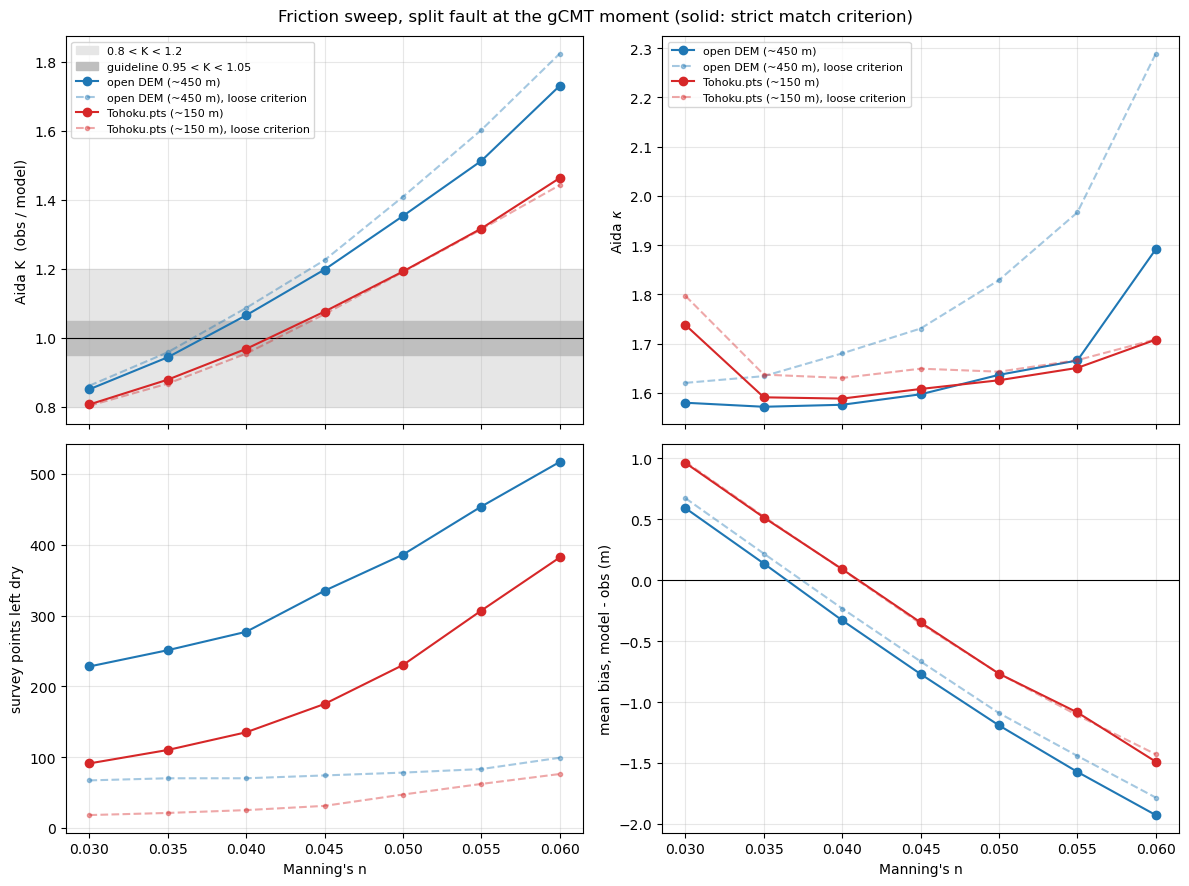

In [5]:
colors = {'open': 'C0', 'pts': 'C3'}
labels = {'open': 'open DEM (~450 m)', 'pts': 'Tohoku.pts (~150 m)'}
n_arr  = np.array(frictions)


def series(dem, key, crit='strict'):
    return np.array([results[dem][n][crit][key] for n in frictions])


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

ax = axes[0, 0]
ax.axhspan(0.8, 1.2, color='0.9', label='0.8 < K < 1.2')
ax.axhspan(0.95, 1.05, color='0.75', label='guideline 0.95 < K < 1.05')
ax.axhline(1.0, color='k', lw=0.8)
ax.set_ylabel('Aida K  (obs / model)')

for key, ax, ylabel in [('kappa', axes[0, 1], 'Aida $\\kappa$'),
                        ('dry',   axes[1, 0], 'survey points left dry'),
                        ('bias',  axes[1, 1], 'mean bias, model - obs (m)')]:
    ax.set_ylabel(ylabel)
axes[1, 1].axhline(0.0, color='k', lw=0.8)

for dem in dems:
    c = colors[dem]
    for key, ax in [('K', axes[0, 0]), ('kappa', axes[0, 1]),
                    ('dry', axes[1, 0]), ('bias', axes[1, 1])]:
        ax.plot(n_arr, series(dem, key), 'o-', color=c, label=labels[dem])
        ax.plot(n_arr, series(dem, key, 'loose'), 'o--', color=c, alpha=0.4,
                ms=3, label=f'{labels[dem]}, loose criterion')

for ax in axes.ravel():
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("Manning's n")
axes[0, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8)
fig.suptitle("Friction sweep, split fault at the gCMT moment (solid: strict match criterion)")
plt.tight_layout()

The DART peak, as a check that the far field is untouched by friction:

In [6]:
for dem in dems:
    d = np.array([results[dem][n]['dart'] for n in frictions])
    print(f'{dem:5s}: DART 21418 peak {d.min():.3f}-{d.max():.3f} m across n = '
          f'{frictions[0]}-{frictions[-1]}  (observed 1.87 m)')

open : DART 21418 peak 1.874-1.874 m across n = 0.03-0.06  (observed 1.87 m)
pts  : DART 21418 peak 1.850-1.850 m across n = 0.03-0.06  (observed 1.87 m)


## The optimum for each DEM

*K* is close to exponential in *n* over this range, so log *K* is interpolated
linearly to find where *K* = 1 exactly.  &kappa; is scale-invariant (see
CLAUDE.md), so it does not share *K*'s optimum and is reported at the chosen
*n* by interpolating along its own curve.

In [7]:
def interp_at_K1(dem, crit='strict'):
    K = series(dem, 'K', crit)
    logK = np.log(K)
    order = np.argsort(logK)
    n_opt = float(np.interp(0.0, logK[order], n_arr[order]))
    at = {key: float(np.interp(n_opt, n_arr, series(dem, key, crit)))
          for key in ['kappa', 'bias', 'rms', 'dry']}
    return n_opt, at


optimum = {}
print(f'{"DEM":6s}{"n (K = 1)":>11}{"kappa":>8}{"bias":>8}{"RMS":>7}{"dry":>6}'
      f'{"n at min kappa":>16}{"min kappa":>11}')
print('-' * 73)
for dem in dems:
    n_opt, at = interp_at_K1(dem)
    kap = series(dem, 'kappa')
    optimum[dem] = n_opt
    print(f'{dem:6s}{n_opt:11.4f}{at["kappa"]:8.2f}{at["bias"]:+8.2f}{at["rms"]:7.2f}'
          f'{at["dry"]:6.0f}{n_arr[kap.argmin()]:16.3f}{kap.min():11.2f}')

DEM     n (K = 1)   kappa    bias    RMS   dry  n at min kappa  min kappa
-------------------------------------------------------------------------
open       0.0374    1.57   -0.09   3.23   263           0.035       1.57
pts        0.0415    1.59   -0.04   3.75   147           0.040       1.59


## Result

| DEM | recommended *n* | K | &kappa; | bias | RMS | dry (of 1765) |
|---|---|---|---|---|---|---|
| open (~450 m) | **0.037** | 1.00 | 1.57 | &minus;0.09 m | 3.23 | 263 |
| `Tohoku.pts` (~150 m) | **0.042** | 1.00 | 1.59 | &minus;0.04 m | 3.75 | 147 |

*(strict criterion, interpolated to K = 1 from the sweep above; measured
2026-09-27.)*

`notebook_tohoku_open_elevation.ipynb` now picks the value to match its
`elevation_source`.

What to take from it:

- **The finer DEM wants ~0.005 more friction**, as expected: it resolves more
  of the low coastal strip, lets more water through, and needs more roughness
  to bring the heights back to K = 1.
- **K and &kappa; now co-optimise on both DEMs.**  &kappa; bottoms at n = 0.035
  (open) and 0.040 (pts), within 0.002 of the K = 1 value.  They did not
  under the old loose criterion (the faint dashed lines), where &kappa; on the
  open DEM climbs steadily from n = 0.030 -- part of what was read as a K/&kappa;
  trade-off was the search radius.
- **The pts DEM wins on extent, not height.**  It leaves 147 survey points dry
  against 263, but its RMS is ~0.5 m worse and its &kappa; is no better.
- **Extent is bought against friction** on both DEMs: the dry count rises
  monotonically with *n*, so a run aimed at inundation extent rather than
  height might take *n* a little below these values.
- **The DART peak does not move with *n*** -- 1.874 m on the open DEM and 1.850
  m on `Tohoku.pts` at every value.  The 0.024 m between the DEMs is not friction; most likely it is
  the source, since the horizontal-push term uses the bathymetric
  gradient and so differs between the two DEMs (not isolated here).